In [35]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
import random
import time

In [36]:
# Đường dẫn đến thư mục chứa ảnh và nhãn
image_dir = 'D://Study//CS406//Do_An//dataset//images'
label_dir = 'D://Study//CS406//Do_An//dataset//labels'

# Đường dẫn tới thư mục train và val
train_image_dir = 'D://Study//CS406//Do_An//dataset//images//train'
train_label_dir = 'D://Study//CS406//Do_An//dataset//labels//train'
val_image_dir = 'D://Study//CS406//Do_An//dataset//images//val'
val_label_dir = 'D://Study//CS406//Do_An//dataset//labels//val'


In [37]:
yolov8l_model = YOLO("D:/Study/CS406/Do_An/dataset/best_150epoch_v8l.pt")
yolov11l_model = YOLO("D:/Study/CS406/Do_An/dataset/best_150epochs_v11l.pt")

In [38]:
results = yolov8l_model.predict(source='D:/Study/CS406/Do_An/dataset/images/val', show=False)



WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2846 D:\Study\CS406\Do_An\dataset\images\val\0008.jpg: 384x640 1 Prohibition Signs, 734.5ms
image 2/2846 D:\Study\CS406\Do_An\dataset\images\val\0015.jpg: 384x640 1 Prohibition Signs, 651.8ms
image 3/2846 D:\Study\CS406\Do_An\dataset\images\val\0016.jpg: 384x640 1 Prohibition Signs, 452.4ms
image 4/2846 D:\Study\CS406\Do_An\dataset\images\val\0024.jpg: 384x640 1 Prohibition Signs, 495.1ms
image 5/2846 D:\Study\CS406\Do_An\dataset\images\val\0027.

In [39]:
metrics = yolov8l_model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50

Ultralytics 8.3.40  Python-3.12.4 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-12450H)


FileNotFoundError: '/kaggle/input/cs406-data/dataset/data.yaml' does not exist

In [24]:
results = yolov11l_model.predict(source='D:/Study/CS406/Do_An/dataset/images/val', show=False)



WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2846 D:\Study\CS406\Do_An\dataset\images\val\0008.jpg: 384x640 1 Prohibition Signs, 410.8ms
image 2/2846 D:\Study\CS406\Do_An\dataset\images\val\0015.jpg: 384x640 1 Prohibition Signs, 282.3ms
image 3/2846 D:\Study\CS406\Do_An\dataset\images\val\0016.jpg: 384x640 1 Prohibition Signs, 269.4ms
image 4/2846 D:\Study\CS406\Do_An\dataset\images\val\0024.jpg: 384x640 1 Prohibition Signs, 271.5ms
image 5/2846 D:\Study\CS406\Do_An\dataset\images\val\0027.

In [33]:
metrics = yolov11l_model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50

Ultralytics 8.3.40  Python-3.12.4 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-12450H)


FileNotFoundError: '/kaggle/input/cs406-data/dataset/data.yaml' does not exist

In [30]:
def predict_image(weights_path, img_path):
    # Load model
    model = YOLO(weights_path)

    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Inference
    start_time = time.time()
    prediction = model(img_path)
    end_time = time.time()

    # Calculate inference time
    inference_time = end_time - start_time
    print(f"Thời gian dự đoán: {inference_time:.2f} giây")

    # Draw bounding boxes and labels
    for box in prediction[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        confidence = box.conf[0].item()
        class_id = int(box.cls[0].item())
        label = f"{model.names[class_id]} ({confidence:.2f})"

        # Draw rectangle and label
        cv2.rectangle(img, (x1, y1), (x2, y2), color=(0, 255, 255), thickness=1)
        cv2.putText(
            img, label, (x1, y1 - 10),
            fontFace=cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=0.5,
            color=(0, 255, 255),
            thickness=1,
            lineType=cv2.LINE_AA,
        )

    # Display result
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()



image 1/1 D:\Study\CS406\Do_An\211-1604.png: 448x640 3 Prohibition Signss, 1 Mandatory Signs, 478.1ms
Speed: 4.6ms preprocess, 478.1ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
Thời gian dự đoán: 0.87 giây


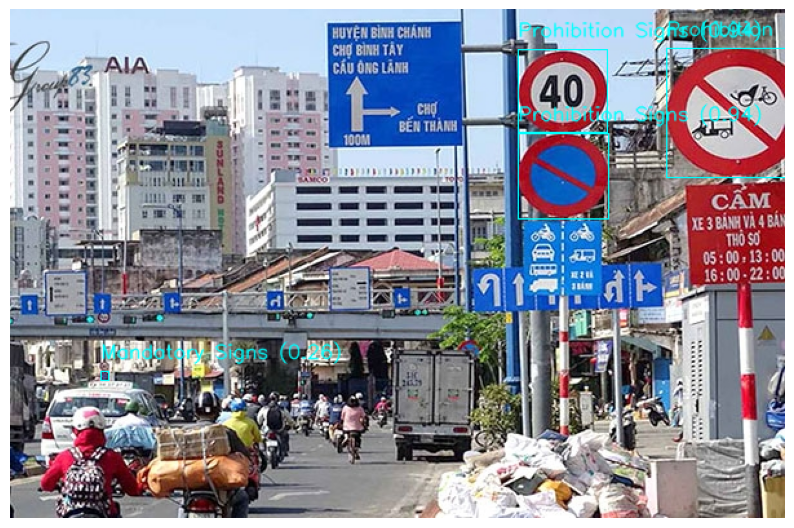

In [31]:
predict_image("D:/Study/CS406/Do_An/dataset/best_150epoch_v8l.pt","D:/Study/CS406/Do_An/211-1604.png")


image 1/1 D:\Study\CS406\Do_An\211-1604.png: 448x640 3 Prohibition Signss, 1 Mandatory Signs, 2 Information Signss, 424.6ms
Speed: 2.0ms preprocess, 424.6ms inference, 0.0ms postprocess per image at shape (1, 3, 448, 640)
Thời gian dự đoán: 0.72 giây


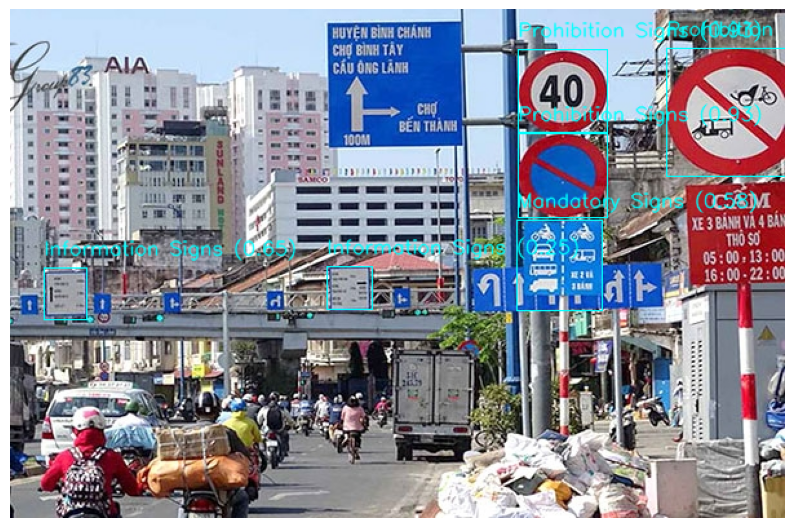

In [32]:
predict_image("D:/Study/CS406/Do_An/dataset/best_150epochs_v11l.pt","D:/Study/CS406/Do_An/211-1604.png")